<a href="https://colab.research.google.com/github/giuliaalberti/analisi-iconografia-annunciazione/blob/main/Analisi_iconografia_Annunciazione.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Humanities e Data Management / Informatica per i Beni Culturali (2025/2026)


#**ANALISI DELL'ICONOGRAFIA DELL'_ANNUNCIAZIONE_**

## 1. Introduzione
Il presente lavoro propone uno studio, articolato nelle fasi esplorativa ed esplicativa, condotto su un corpus di opere d'arte figurativa realizzate in un arco temporale compreso tra il XIII e il XXI secolo.

I dati originali sono stati estratti direttamente dal repository remoto in formato CSV presente al seguente link: https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv

Successivamente elaborati all'interno dell'ambiente di calcolo interattivo Google Colab.
Per la manipolazione e l'interpretazione del dataset è stato impiegato il linguaggio Python, avvalendosi in particolare di tre librerie fondamentali per il Data Management umanistico:

`pandas` per la modellazione, la strutturazione e la pulizia dei dati tabellari;

`numpy` per la gestione avanzata dei valori mancanti (missing values) e le operazioni vettoriali;

`matplotlib` per la sintesi visiva e la generazione dei grafici a supporto delle ipotesi interpretative.

L'indagine si è sviluppata a partire da un'ispezione preliminare del dataset (Exploratory Data Analysis), essenziale per comprendere la qualità dei metadati, identificare eventuali lacune informative e formulare domande di ricerca rilevanti per la disciplina storico-artistica.

## 1.1 Obiettivi
Il seguente progetto si propone di rispondere alle seguenti domande di ricerca:
1. In quale arco temporale si concentra la maggior presenza dell'iconografia dell'Annunciazione e quali sono i principali stili artistici che caratterizzano la produzione?
2. Analizzare l'area dei quadri raffiguranti l'_Annunciazione_' nei diversi secoli. Osserviamo come si distruibuisce negli anni la grandezza dell'annunciazione.
3.  I luoghi con maggiore frequenza dell'_Annunciazione_.

## 1.2 Dati utilizzati
I dati in input sono costituiti da un file CSV di 229.3+ KB scaricato da una repository GitHub del corso Digital Humanities e Data Management per I Beni Culturali - Informatica per I Beni Culturali dell'anno 2025/2026 (https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/lispod/data.csv).
I dati in output consistono in questo Jupyter Notebook, contenente testo e codice per l'analisi computazionale dei dati.
 Le variabili considerate sono:

| Variabile | Tipo |	Definizione | Esempio |
| :------- | :--- | :--------- | :------ |
|  id     |	str | link ID dell'opera | 	http://www.wikidata.org/entity/Q368788	 |
| titolo | str | titolo dell'opera | Pietà |
| artisti | str | nome dell'artista | Perugino |
| data_creazione | int | anno di creazione dell'opera | 1483 |
| generi | str | generi ai quali l'opera afferisce | arte religiosa |
| luoghi | str | luogo di conservazione dell'opera | Palazzo degli Uffizi|
| collezioni | str | collezione alla quale l'opera appartiene | Palazzo degli Uffizi|
| contenuti | str | contenuto dell'opera | Gesù; donna; Maria; uomo|
| movimenti | str | movimenti artistici ai quali l'opera afferisce | rinascimento italiano |
soggetti | str | soggetti rappresentati | Pietà |
| altezza | float | altezza dell'opera in cm | 168.0 |
| larghezza | float | larghezza dell'opera in cm | 176.0 |
| area opera | float | area dell'opera in cm² | 29568.00|

##1.3 Organizzazione
Questo Jupyter Notebook è stato sviluppato in un ambiente Google Colaboratory. Tutte le operazioni di caricamento, ispezione, processamento e analisi dei dati sono state eseguite direttamente all'interno di questo notebook, utilizzando le librerie Python standard come Pandas per la manipolazione dei dati e Matplotlib per la visualizzazione. I dati di input sono stati richiamati direttamente dalla fonte esterna (repository GitHub) all'inizio del notebook e tutti i risultati dell'analisi sono contenuti nelle celle di output.


## 1.4  Preservazione
Il codice sviluppato nell’ambito del presente lavoro è conservato su GitHub, che ne supporta il versionamento, e su Zenodo, che ne garantisce l’archiviazione a lungo termine e la citabilità tramite DOI.

 **Responsabili**
- Alberti Giulia
- Corrado Valentina


## 1.5 Accesso e Utilizzo
I dati di input sono rilasciati sotto licenza CC0 1.0 Universal.

Il codice è rilasciato sotto licenza CC0 1.0 Universal.

I dati di output sono rilasciati sotto licenza CC0 1.0 Universal.


## 2. Caricamento e ispezione dei dati
Il primo passaggio che abbiamo effettuato è stato importare le librerie  `Pandas`, `NumPy` e `Matplotlib.pyplot`.

Succesivamente abbiamo creato un DataFrame con i dati contenuti all'interno del [file CSV ] fornito (https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/lispod/data.csv).

In [1]:
import pandas as pd # per la modellazione, la strutturazione e la pulizia dei dati tabellari
import numpy as np # per la gestione avanzata dei valori mancanti (missing values) e le operazioni vettoriali
import matplotlib.pyplot as plt #  per la sintesi visiva e la generazione dei grafici a supporto delle ipotesi interpretative

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv")
df

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,Galleria Palatina,Galleria Palatina,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento,Tommaso Inghirami,91.0,61.0
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto; ritratto di gruppo,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta,papa Paolo III,210.0,176.0
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,nudo artistico; pittura mitologica,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,NaN,NaN,102.0,131.0
2440,http://www.wikidata.org/entity/Q136747345,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898,ritratto,Palazzo Frizzoni,Accademia Carrara; Palazzo Frizzoni,Antonio Agliardi,NaN,Antonio Agliardi,140.0,112.0
2441,http://www.wikidata.org/entity/Q136789581,Scena amorosa,NaN,1600,arte di genere,Casa Buonarroti,Casa Buonarroti,donna; uomo; partner,pittura veneta,NaN,74.5,66.5
2442,http://www.wikidata.org/entity/Q136849352,San Benedetto Revelli,NaN,1700,arte religiosa,chiesa di Santa Maria in Fontibus,chiesa di Santa Maria in Fontibus,Benedetto Revelli,NaN,Benedetto Revelli,220.0,150.0


A questo punto procediamo con l'ispezione: per avere una panoramica generale dei dati analizziamo il Dataset tramite i metodi  `.head()`, `.iloc()`  `.tail()` .

In [3]:
df.head()

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,Galleria Palatina,Galleria Palatina,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento,Tommaso Inghirami,91.0,61.0
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto; ritratto di gruppo,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta,papa Paolo III,210.0,176.0
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0


In [4]:
#scegliamo un intervallo di indici specifici a nostra scelta
df.iloc[30:40]

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
30,http://www.wikidata.org/entity/Q945625,Stigmate di san Francesco,Michelangelo Buonarroti (maschio),1500,arte religiosa,NaN,NaN,uomo; stigmate; Francesco d'Assisi,Alto Rinascimento,Stimmate di San Francesco,NaN,NaN
31,http://www.wikidata.org/entity/Q924655,Trafugamento del corpo di san Marco,Jacopo Tintoretto (maschio),1564,arte religiosa,Gallerie dell'Accademia,Gallerie dell'Accademia,Venezia; colonna; Marco; cadavere; via ad arco,manierismo; pittura veneta,NaN,398.0,315.0
32,http://www.wikidata.org/entity/Q945250,Ritratto di Francesco delle Opere,Perugino (maschio),1494,ritratto,Palazzo degli Uffizi,Palazzo degli Uffizi,paesaggio,Alto Rinascimento,NaN,52.0,44.0
33,http://www.wikidata.org/entity/Q955295,Madonna di Macerata,Carlo Crivelli (maschio),1470,arte religiosa,Musei civici di Palazzo Buonaccorsi,Macerata Musei; Musei civici di Palazzo Buonac...,Maria; donna; ragazzo; madre; Bambino Gesù; Ma...,pittura rinascimentale italiana,Madonna col Bambino,61.9,41.0
34,http://www.wikidata.org/entity/Q1115423,Compianto sul Cristo morto,Sandro Botticelli (maschio),1490 | 1495,arte religiosa,Museo Poldi Pezzoli; chiesa di Santa Maria Mag...,Museo Poldi Pezzoli,Gesù; Maria; uomo; preghiera; santo; Maria Mad...,Primo Rinascimento,Compianto sul Cristo morto,106.0,71.0
35,http://www.wikidata.org/entity/Q1115413,Storie di Virginia,Sandro Botticelli (maschio),1501,pittura mitologica,Accademia Carrara,Accademia Carrara,Verginia,Primo Rinascimento,NaN,85.0,165.0
36,http://www.wikidata.org/entity/Q1119008,Pala di Asolo,NaN,1506,arte religiosa,duomo di Asolo,duomo di Asolo,Maria; donna; piante; uomo; nuvola; Assunzione...,Alto Rinascimento,Assunzione di Maria,175.0,162.0
37,http://www.wikidata.org/entity/Q1119782,Disputa di Simon Mago e crocifissione di san P...,Filippino Lippi (maschio),1481,arte religiosa,cappella Brancacci,cappella Brancacci,Roma; Nerone; Sandro Botticelli; uomo; Pietro;...,Alto Rinascimento,NaN,230.0,598.0
38,http://www.wikidata.org/entity/Q1121644,Barrocci romani,Giovanni Fattori (maschio),1873,arte di genere,Palazzo Pitti,Galleria d'arte moderna di Firenze,Equus ferus caballus; uomo; carro,Macchiaioli,NaN,21.0,31.0
39,http://www.wikidata.org/entity/Q1122002,Polittico di San Vincenzo Ferrer,Giovanni Bellini (maschio),1500,arte religiosa,basilica dei Santi Giovanni e Paolo,basilica dei Santi Giovanni e Paolo,Gesù; Maria; donna; uomo; ragazzo; preghiera; ...,pittura rinascimentale italiana,Pietà,275.0,31.0


In [5]:
#ora controlliamo le ultime righe
df.tail()

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,nudo artistico; pittura mitologica,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,NaN,NaN,102.0,131.0
2440,http://www.wikidata.org/entity/Q136747345,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898,ritratto,Palazzo Frizzoni,Accademia Carrara; Palazzo Frizzoni,Antonio Agliardi,NaN,Antonio Agliardi,140.0,112.0
2441,http://www.wikidata.org/entity/Q136789581,Scena amorosa,NaN,1600,arte di genere,Casa Buonarroti,Casa Buonarroti,donna; uomo; partner,pittura veneta,NaN,74.5,66.5
2442,http://www.wikidata.org/entity/Q136849352,San Benedetto Revelli,NaN,1700,arte religiosa,chiesa di Santa Maria in Fontibus,chiesa di Santa Maria in Fontibus,Benedetto Revelli,NaN,Benedetto Revelli,220.0,150.0
2443,http://www.wikidata.org/entity/Q137169658,"Ritratto di fanciulla, ""Violante""",Giovanni Cariani (maschio),1600,ritratto,Galleria Estense,Galleria Estense,parapetto; donna giovane,pittura veneta; Alto Rinascimento,donna giovane,90.0,65.0


In [6]:
# ora vediamo il numero di righe e il numero di colonne
df.shape

(2444, 12)

In [7]:
# osserviamo elenco delle colonne con il conteggio dei valori non-nulli e il loro tipo per ognuna
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2444 non-null   object 
 1   titolo          2444 non-null   object 
 2   artisti         2159 non-null   object 
 3   data_creazione  1478 non-null   object 
 4   generi          1524 non-null   object 
 5   luoghi          2362 non-null   object 
 6   collezioni      2236 non-null   object 
 7   contenuti       2021 non-null   object 
 8   movimenti       382 non-null    object 
 9   soggetti        1666 non-null   object 
 10  altezza         1281 non-null   float64
 11  larghezza       1269 non-null   float64
dtypes: float64(2), object(10)
memory usage: 229.3+ KB


In [8]:
df.columns

Index(['id', 'titolo', 'artisti', 'data_creazione', 'generi', 'luoghi',
       'collezioni', 'contenuti', 'movimenti', 'soggetti', 'altezza',
       'larghezza'],
      dtype='object')

In questa fase di esplorazione dei dati sono emerse due criticità:

- Tipo di dato errato: il campo `data_creazione` è attualmente rilevato come `object` e necessita di essere convertito nel formato corretto.

- Valori mancanti: si riscontra un'assenza di dati nei campi `movimenti` , `altezza`, `larghezza`.


Nei dati de-normalizzati è comune trovare duplicazioni. Quindi è opportuno  verificare che non siano presenti righe ripetute, utilizzando il metodo `.duplicated()` associato a `.value_counts()`.

In [9]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
2439,False
2440,False
2441,False
2442,False


In [10]:
#utilizziamo il metodo .value_counts() per il conteggio
print(df.duplicated().value_counts())

False    2444
Name: count, dtype: int64


Bene non risultano righe duplicate ma ora continuiamo il controllo dei dati duplicati verificando il numero di valori unici per ogni colonna, utilizzando `.nunique()`.

In [11]:
df.nunique()

,0
id,2444
titolo,2057
artisti,880
data_creazione,495
generi,48
luoghi,649
collezioni,508
contenuti,1376
movimenti,55
soggetti,763


Prima di procedere con analisi più approfondite, utilizziamo il metodo `.describe()` per osservare la distribuzione complessiva dei dati, identificando così eventuali anomalie o tendenze generali.

In [12]:
# questa funzione ci restituisce il conteggio, la media, la deviazione standard, il minimo, il massimo dei nostri dati quantitativi.
df.describe()

,altezza,larghezza
count,1281.000000,1269.000000
mean,154.342873,138.294460
std,249.023405,242.695832
min,1.220000,3.170000
25%,69.000000,58.000000
50%,111.000000,92.000000
75%,194.000000,157.000000
max,7200.000000,5454.000000


## **3. Processamento**
Ora procediamo con la pulizia dei dati attraverso le seguenti operazioni:

1. L'`altezza` e la `larghezza` minima e massima presentano delle anomalie, occorre quindi normalizzarle.

2. Come abbiamo visto i valori della colonna `data_creazione` risultano come `object`. È quindi necessario trasformarli in `int`;

3. I valori delle colonne `soggetti` e `movimenti` necessitano invece di essere normalizzati prima di essere utilizzati per svolgere qualsiasi tipo di analisi. Alcuni presentano la prima lettera maiuscola, altri minuscola

4. Alcune colonne contengono informazioni separate da `;`
Procederemo alla loro normalizzazione così da poterle analizzare ai fini della nostra ricerca.


###3.1. Normalizzazione e pulizia delle dimensioni (altezza e larghezza)

Nel corso dell'ispezione dei dati sono emersi valori anomali nelle variabili relative alle dimensioni massime e minime (`altezza` e `larghezza`). È necessaria una fase di normalizzazione per rendere i dati omogenei ed esenti da distorsioni.

In questa fase si applicano le seguenti regole di pulizia:
Rimozione dei record incompleti: eliminare le righe che riportano l'altezza ma privi della misura della larghezza.

Iniziamo a lavorare sui valori minimi sospetti di `altezza` e `larghezza`.
Utilizziamo `.loc` per individuare il record che presenta come altezza il valore `1.22`

In [13]:
df.loc[df["altezza"] == 1.220000]

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
2321,http://www.wikidata.org/entity/Q132397679,Il corteo del carro d'oro del principe Borghese,Giovan Paolo Schor (maschio),1664,vedutismo,deposito del museo,Palazzo degli Uffizi,Roma; carrozza; Carnevale di Roma; Mascarata; ...,NaN,Carnevale di Roma,1.22,3.17


Abbiamo verificato tramite il link della colonna  `id` e abbiamo scoperto che su Wikidata le misure dell'altezza e della larghezza sono espresse in metri. Risulta necessario convertire le misure in centimetri, rendendole conformi a quelle del resto  del DataSet.

In [14]:
# Aggiorniamo i valori

df.loc[2321, 'altezza'] = df.loc[2321, 'altezza'] * 100
df.loc[2321, 'larghezza'] = df.loc[2321, 'larghezza'] * 100

In [15]:
# Verifichiamo che i valori siano stati aggiornati

display(df.loc[2321, ['altezza', 'larghezza']])

,2321
altezza,122.0
larghezza,317.0


Continuando a fare verifiche con la funzione `.describe` notiamo un'anomalia anche per i valori massimi, in cui  l'altezza massima risulta essere 7200 cm e la larghezza 5454 cm.
Ora procediamo a verificare quale dipinto presenta questi valori.

In [16]:
# Controllo quale opera presenta altezza 7200.0

df.loc[df["altezza"] == 7200.000000]

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
314,http://www.wikidata.org/entity/Q7720644,Sepoltura e gloria di santa Petronilla,Guercino (maschio),1623,arte religiosa,Musei capitolini,Musei capitolini,Santa Petronilla,NaN,NaN,7200.0,4230.0


Controllando il link di Wikidata scopriamo che le misure sono espresse in *millimetri*, perciò è necessario convertirle in *centimetri*.

In [17]:
#convertiamo i valori attraverso una formula matematica
df.loc[314, 'altezza'] = df.loc[314, 'altezza'] / 10
df.loc[314, 'larghezza'] = df.loc[314, 'larghezza'] / 10

In [18]:
#verifichiamo  che la conversione dell'unità di misura sia stata effettuata correttamente
display(df.loc[314, ['altezza', 'larghezza']])

,314
altezza,720.0
larghezza,423.0


Ora dobbiamo capire quale opera presenta come **larghezza** il valore 5454. Come abbiamo fatto per gli altri valori, verifichiamo il link e controlliamo le dimensioni per capire quale conversione ci sia bisogno di fare.

In [19]:
df.loc[df["larghezza"] == 5454.000000]

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
105,http://www.wikidata.org/entity/Q2717478,Madonna della Loggia,Sandro Botticelli (maschio),1467,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Maria; donna; ragazzo; madre; Bambino Gesù,Primo Rinascimento,Madonna col Bambino,72.0,5454.0


Dal controllo su Wikidata abbiamo riscontrato un errore. In questo caso  non abbiamo a che fare con un errore di conversione ma si tratta di un valore sbagliato. Lo correggiamo subito: da `5454` a `50`.

In [20]:
df.loc[105, 'larghezza'] = 50

In [21]:
display(df.loc[105, ['larghezza']])

,105
larghezza,50.0


Bene, ora per sicurezza andiamo a osservare ulteriormente il DataSet per capire se sono presenti altre anomalie

In [22]:
df.describe()

,altezza,larghezza
count,1281.000000,1269.000000
mean,149.378610,131.283294
std,153.095441,153.117389
min,11.500000,7.300000
25%,69.000000,58.000000
50%,111.000000,92.000000
75%,194.000000,157.000000
max,2860.000000,2450.000000


Ora facciamo una ricerca ulteriore: vogliamo vedere quali sono i quadri che presentano un altezza e una larghezza maggiore di 750 cm per controllare che non ci siano valori sospetti.



In [23]:
df[(df["altezza"] > 750) | (df["larghezza"] > 750)]

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
45,http://www.wikidata.org/entity/Q1237596,Vertumno e Pomona,Pontormo (maschio),1519,pittura mitologica,Villa medicea di Poggio a Caiano,Villa medicea di Poggio a Caiano; Villa Medici,Vertumno,NaN,NaN,461.0,990.0
120,http://www.wikidata.org/entity/Q3223625,San Giovanni Battista,Caravaggio (maschio),1602,nudo artistico; arte religiosa,Musei capitolini,Musei capitolini,piante; nudità; Giovanni Battista; montone; pa...,NaN,Giovanni Battista,1290.0,950.0
136,http://www.wikidata.org/entity/Q3620765,Apoteosi di Angelo della Vecchia nel segno del...,Giambattista Tiepolo (maschio),1760,arte religiosa,Palazzo Pozzobonelli-Isimbardi,Palazzo Pozzobonelli-Isimbardi,apoteosi,rococò,NaN,800.0,600.0
169,http://www.wikidata.org/entity/Q3752977,Fregio delle arti liberali e meccaniche,Giorgione (maschio),1496,natura morta,Casa Giorgione,Casa Giorgione,Artes mechanicae; arti liberali,NaN,arti liberali,77.0,1588.0
173,http://www.wikidata.org/entity/Q3769202,Giudizio finale e Inferno,Buonamico Buffalmacco (maschio),1336,arte religiosa,Camposanto monumentale,Camposanto monumentale,NaN,NaN,NaN,600.0,860.0
198,http://www.wikidata.org/entity/Q3842575,Madonna col Bambino tra i santi Giovanni Batti...,Jacopo Palma il Vecchio (maschio),1520,arte religiosa,Palazzo Rosso,Musei di Strada Nuova,Maria; capelli lunghi; Giovanni Battista; Mari...,pittura veneta; Alto Rinascimento,Sacra conversazione,710.0,1080.0
229,http://www.wikidata.org/entity/Q3910087,Predica di san Marco ad Alessandria d'Egitto,Giovanni Bellini (maschio); Gentile Bellini (m...,1500,arte religiosa,Pinacoteca di Brera,Pinacoteca di Brera,Alessandria d'Egitto; cupola; Giraffa; torre; ...,Rinascimento,NaN,347.0,770.0
272,http://www.wikidata.org/entity/Q3982379,Tebaide,Buonamico Buffalmacco (maschio),1336,arte religiosa,Camposanto monumentale,Camposanto monumentale,NaN,NaN,NaN,610.0,1560.0
288,http://www.wikidata.org/entity/Q3998940,Trionfo della Morte,Buonamico Buffalmacco (maschio),1336,arte religiosa,Camposanto monumentale,Camposanto monumentale,Trionfo della Morte,NaN,NaN,560.0,1500.0
411,http://www.wikidata.org/entity/Q28803759,Dio Padre e un angelo,Guercino (maschio),1620,arte religiosa,Musei di Strada Nuova,Musei di Strada Nuova,Dio Padre; angelo,NaN,Dio Padre,660.0,910.0


Sempre eseguendo una verifica su Wikidata abbiamo riscontrato che le opere nelle **righe 120, 411, 412, 413, 414, 1857** contengo degli errori nelle unità di misura; infatti anche se tutte le misure nelle colonne altezza e larghezza sono state espresse in cm quelle lì sono in mm. Per tale ragione si corregono i valori riportandoli nella misura corretta.


In [24]:
# correzione valori della riga 120
df.loc[120, 'altezza'] = df.loc[120, 'altezza'] / 10
df.loc[120, 'larghezza'] = df.loc[120, 'larghezza'] / 10

# correzione valori della riga 411
df.loc[411, 'altezza'] = df.loc[411, 'altezza'] / 10
df.loc[411, 'larghezza'] = df.loc[411, 'larghezza'] / 10

# correzione valori della riga 412
df.loc[412, 'altezza'] = df.loc[412, 'altezza'] / 10
df.loc[412, 'larghezza'] = df.loc[412, 'larghezza'] / 10

# correzione valori della riga 413
df.loc[413, 'altezza'] = df.loc[413, 'altezza'] / 10
df.loc[413, 'larghezza'] = df.loc[413, 'larghezza'] / 10

# correzione valori della riga 414
df.loc[414, 'altezza'] = df.loc[414, 'altezza'] / 10
df.loc[414, 'larghezza'] = df.loc[414, 'larghezza'] / 10

#correzione valori della riga 1857
df.loc[1857, 'altezza'] = df.loc[1857, 'altezza'] / 10
df.loc[1857, 'larghezza'] = df.loc[1857, 'larghezza'] / 10

#fverifichiamo che  le righe selezionate 120, 411, 412, 413, 414 e 1857 siano state corrette
display(df.iloc[[120, 411, 412,413, 414, 1857]])

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
120,http://www.wikidata.org/entity/Q3223625,San Giovanni Battista,Caravaggio (maschio),1602,nudo artistico; arte religiosa,Musei capitolini,Musei capitolini,piante; nudità; Giovanni Battista; montone; pa...,NaN,Giovanni Battista,129.0,95.0
411,http://www.wikidata.org/entity/Q28803759,Dio Padre e un angelo,Guercino (maschio),1620,arte religiosa,Musei di Strada Nuova,Musei di Strada Nuova,Dio Padre; angelo,NaN,Dio Padre,66.0,91.0
412,http://www.wikidata.org/entity/Q28809144,Clorinda salva Olindo e Sofronia dal rogo,Mattia Preti (maschio),1646,NaN,Musei di Strada Nuova; Palazzo Rosso,Musei di Strada Nuova,Clorinda; Olindo e Sofronia,NaN,Olindo e Sofronia,248.0,245.0
413,http://www.wikidata.org/entity/Q28803484,Ritratto di Paolina Adorno Brignole-Sale,Antoon van Dyck (maschio),1627,ritratto,Palazzo Rosso,Musei di Strada Nuova,Paola Adorno Brignole Sale,NaN,Paola Adorno Brignole Sale,286.0,151.0
414,http://www.wikidata.org/entity/Q28803789,Giovanni Francesco II Brignole-Sale,Hyacinthe Rigaud (maschio),1739,ritratto,Palazzo Rosso,Musei di Strada Nuova,Giovanni Francesco II Brignole Sale,NaN,Giovanni Francesco II Brignole Sale,101.0,80.0
1857,http://www.wikidata.org/entity/Q131546520,Bocc,Barbara Galbiati (femmina),1994,NaN,Galleria all'aperto dell'affresco di Arcumeggia,Galleria all'aperto dell'affresco di Arcumeggia,capro,NaN,NaN,74.0,81.0


In [25]:
#ricontrolliamo il nostro DataFrame
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2444 non-null   object 
 1   titolo          2444 non-null   object 
 2   artisti         2159 non-null   object 
 3   data_creazione  1478 non-null   object 
 4   generi          1524 non-null   object 
 5   luoghi          2362 non-null   object 
 6   collezioni      2236 non-null   object 
 7   contenuti       2021 non-null   object 
 8   movimenti       382 non-null    object 
 9   soggetti        1666 non-null   object 
 10  altezza         1281 non-null   float64
 11  larghezza       1269 non-null   float64
dtypes: float64(2), object(10)
memory usage: 229.3+ KB


Ora procediamo con la creazione di una nuova colonna, `area` che risulterà molto utile per le nostre ricerche.
La generazione della colonna  `area` verrà effettuata esclusivamente sulle osservazioni che dispongono di entrambe le dimensioni idonee.

In [26]:
df["area"] = df["altezza"] * df["larghezza"]
#Visualizzazione specifica delle colonne dimensionali
# Selezioniamo solo le colonne rilevanti per controllare subito i calcoli
display(df[["altezza", "larghezza", "area"]].head(10))

# Verifica quantitativa della copertura del metadato 'area'
opere_con_area = df["area"].notna().sum() #Qui si conta quante opere hanno un valore valido (non mancante) nella colonna
totale_opere = len(df)
print(
    f"Opere con superficie calcolabile: {opere_con_area} su {totale_opere} "
    f"({opere_con_area/totale_opere*100:.1f}%)"
)

,altezza,larghezza,area
0,91.0,61.0,5551.00
1,172.5,278.5,48041.25
2,210.0,176.0,36960.00
3,168.0,176.0,29568.00
4,207.0,319.0,66033.00
5,111.0,134.0,14874.00
6,114.0,93.5,10659.00
7,115.0,53.0,6095.00
8,68.0,81.0,5508.00
9,87.0,60.0,5220.00


Opere con superficie calcolabile: 1268 su 2444 (51.9%)


In [27]:
# controlliamo la panoramica generale del nostro dataframe
# Vediamo quanti valori validi sono presenti nella colonna Area
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2444 non-null   object 
 1   titolo          2444 non-null   object 
 2   artisti         2159 non-null   object 
 3   data_creazione  1478 non-null   object 
 4   generi          1524 non-null   object 
 5   luoghi          2362 non-null   object 
 6   collezioni      2236 non-null   object 
 7   contenuti       2021 non-null   object 
 8   movimenti       382 non-null    object 
 9   soggetti        1666 non-null   object 
 10  altezza         1281 non-null   float64
 11  larghezza       1269 non-null   float64
 12  area            1268 non-null   float64
dtypes: float64(3), object(10)
memory usage: 248.3+ KB


Dalla tabella si riscontra che nella colonna dell'area sono presenti **1268 valori non nulli**. Per un ulteriore controllo si esegue una stringa di codice che conteggi quante sono le righe che presentano sia il valore dell'altezza  che della larghezza per verificare il numero di celle non nulle dell'area.

Continuamo con la nostra analisi con una veloce panoramica controllando i dati nulli del DataFrame con i metodi `.isnull` e `.sum` per visualizzare la distribuzione dei valori mancanti all'interno del DataFrame.

In [28]:
df.isnull()

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,area
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2439,False,False,False,False,False,True,True,False,True,True,False,False,False
2440,False,False,False,False,False,False,False,False,True,False,False,False,False
2441,False,False,True,False,False,False,False,False,False,True,False,False,False
2442,False,False,True,False,False,False,False,False,True,False,False,False,False


In [29]:
df.isnull().sum()

,0
id,0
titolo,0
artisti,285
data_creazione,966
generi,920
luoghi,82
collezioni,208
contenuti,423
movimenti,2062
soggetti,778


###3.2 Formattazione di  `data_creazione` e calcolo del secolo

Ora ci occupiamo dei valori della colonna `data_creazione`, la quale è memorizzata come stringa (`object`).
Per procedere con l'elaborazione quantitativa, applichiamo le seguenti trasformazioni:
- Conversione: trasformazione dei valori dell'anno da object a intero (Int)
- Creazione della colonna secolo: calcolo ed estrazione del secolo di riferimento a partire dall'anno di creazione, necessario per i successivi raggruppamenti temporali.

In [30]:
#rivediamo le informazioni
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2444 non-null   object 
 1   titolo          2444 non-null   object 
 2   artisti         2159 non-null   object 
 3   data_creazione  1478 non-null   object 
 4   generi          1524 non-null   object 
 5   luoghi          2362 non-null   object 
 6   collezioni      2236 non-null   object 
 7   contenuti       2021 non-null   object 
 8   movimenti       382 non-null    object 
 9   soggetti        1666 non-null   object 
 10  altezza         1281 non-null   float64
 11  larghezza       1269 non-null   float64
 12  area            1268 non-null   float64
dtypes: float64(3), object(10)
memory usage: 248.3+ KB


In [31]:
# 1. Definiamo una nuova funzione personalizzata con 'def'
# Le diamo un nome descrittivo e diciamo che accetta un parametro d'ingresso 'data' (il contenuto di una singola cella).
def converti_data_creazione_inline(data):

 # 2. pd.isna(data) controlla se il valore nella cella è mancante (NaN/null).
    if pd.isna(data):
        # 3. Se la cella è vuota, restituisce subito il valore nullo ufficiale di Pandas (pd.NA) ed esce dalla funzione.
        return pd.NA

    # 4. Converte 'data' in una stringa di testo con str() e rimuove gli spazi vuoti all'inizio e alla fine con .strip().
    str_data = str(data).strip()

    # 5. Controlla se la stringa è rimasta vuota (ad esempio se la cella conteneva soltanto spazi).
    if not str_data:
        # 6. Se è vuota, restituisce un valore nullo (pd.NA).
        return pd.NA

    # 7. Inizializza la variabile 'anno_to_convert' salvando momentaneamente l'intera stringa pulita.
    anno_to_convert = str_data

    # 8. Controlla se nella stringa è presente la sequenza di caratteri ' | ' (usata per separare date doppie).
    if ' | ' in str_data:
        # 9. Spezza la stringa in più parti usando ' | ' come punto di taglio, creando una lista di elementi (parts).
        parts = str_data.split(' | ')
        # 10. Verifica che la lista creata non sia vuota.
        if parts:
            # 11. Estrae il primo elemento della lista (parts[0], cioè la prima data a sinistra) e rimuove eventuali spazi residui.
            anno_to_convert = parts[0].strip()

    # 12. Avvia un blocco 'try' per tentare una trasformazione numerica senza far crashare il programma in caso di errore.
    try:
        # 13. Converti prima in numero decimale float() per gestire casi come '1510.0', e poi in numero intero int().
        return int(float(anno_to_convert))

    # 14. Intercetta l'errore 'ValueError', che si verifica se la stringa contiene lettere o caratteri non convertibili in numero (es. "circa").
    except ValueError:
        # 15. Se si verifica l'errore, assegna alla cella il valore nullo pd.NA.
        return pd.NA

# 16. Applica la funzione 'converti_data_creazione_inline' a ciascun elemento della colonna 'data_creazione' usando .apply().
df['data_creazione'] = df['data_creazione'].apply(converti_data_creazione_inline)

# 17. Converte l'intera colonna nel formato 'Int64' (con la "I" maiuscola), che supporta numeri interi insieme a valori mancanti (pd.NA).
df['data_creazione'] = df['data_creazione'].astype("Int64")

A partire dall’anno calcoliamo il secolo di riferimento tramite un semplice passaggio matematico. I valori non interpretabili vengono trasformati in valori nulli (`NaN`).

In [32]:
# Definizamo un'altra funzione e le diamo un nome descrittivo e diciamo che accetta un parametro d'ingresso 'anno' (il contenuto di una singola cella).
def converti_anno_in_secolo(anno):
    # 2. pd.isna(anno) controlla se il valore nella cella è mancante (NaN/pd.NA).
    if pd.isna(anno):
        # 3. Se la cella è vuota, restituisce subito il valore nullo ufficiale di Pandas (pd.NA) ed esce dalla funzione.
        return pd.NA
    # 4. Avvia un blocco 'try' per tentare il calcolo senza far crashare il programma in caso di errore.
    try:
        # 5. Converte 'anno' in intero puro (serve perché la colonna è Int64, un tipo "nullable" di Pandas
        #    che alcune operazioni matematiche non gestiscono direttamente).
        anno_int = int(anno)
        # 6. Formula per ricavare il secolo da un anno:
        #    si sottrae 1 (per gestire correttamente i cambi di secolo, es. 1500 -> XV secolo, non XVI),
        #    si fa la divisione intera per 100 (//) e si aggiunge 1.
        #    Esempio: 1564 -> (1564-1)//100 + 1 = 15 + 1 = 16 -> XVI secolo.
        secolo = (anno_int - 1) // 100 + 1
        # 7. Restituisce il numero del secolo calcolato.
        return secolo
    # 8. Intercetta eventuali errori imprevisti (es. valori non numerici sfuggiti ai controlli precedenti).
    except (ValueError, TypeError):
        # 9. In caso di errore, assegna alla cella il valore nullo pd.NA.
        return pd.NA

Con la funzione `secolo` abbiamo aggiunto una nuova colonna alla tabella e nella colonna sono indicati i secoli della creazione di ogni opera. Questo passaggio è molto utile perchè ci aiuta poi a rappresentare in maniera visiva la dispersione delle opere per secolo.

In [33]:
df['secolo'] = df['data_creazione'].apply(converti_anno_in_secolo)

# Converte la nuova colonna nel formato 'Int64', che supporta
# sia numeri interi sia valori mancanti (pd.NA).
df['secolo'] = df['secolo'].astype("Int64")

# Conta quante celle della colonna 'secolo' non sono nulle
n_secolo_noto = df['secolo'].notna().sum()

print(f"Numero di opere con secolo noto: {n_secolo_noto}")

# Verifica del risultato
print(df[['data_creazione', 'secolo']].head(10))

Numero di opere con secolo noto: 1478
   data_creazione  secolo
0            1510      16
1            1485      15
2            1546      16
3            1483      15
4            1480      15
5            1475      15
6            1610      17
7            1545      16
8            1483      15
9            1465      15


In [34]:
# controlliamo le prime 8 righe del dataframe
df.head(8)

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,area,secolo
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,Galleria Palatina,Galleria Palatina,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento,Tommaso Inghirami,91.0,61.0,5551.00,16
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5,48041.25,15
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto; ritratto di gruppo,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta,papa Paolo III,210.0,176.0,36960.00,16
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0,29568.00,15
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0,66033.00,15
5,http://www.wikidata.org/entity/Q488825,Adorazione dei Magi,Sandro Botticelli (maschio),1475,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Maria; Sandro Botticelli; Laurus nobilis; Giov...,Primo Rinascimento; pittura rinascimentale ita...,Adorazione dei Magi,111.0,134.0,14874.00,15
6,http://www.wikidata.org/entity/Q532486,Giuditta con la sua ancella,Artemisia Gentileschi (femmina),1610,arte religiosa,Palazzo Pitti,Galleria Palatina,Giuditta e Oloferne; Giuditta,NaN,Giuditta e Oloferne,114.0,93.5,10659.00,17
7,http://www.wikidata.org/entity/Q493792,Ritratto di Andrea Doria nelle vesti di Nettuno,Agnolo Bronzino (maschio),1545,nudo artistico; allegoria; portrait historié,Pinacoteca di Brera,Pinacoteca di Brera,Nettuno; nudità; Andrea Doria; albero; trident...,manierismo,Andrea Doria,115.0,53.0,6095.00,16


In [35]:
# visualizziamo ulteriormente le informazione del dataframe con l'aggiunta della nuova colonna secolo
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2444 non-null   object 
 1   titolo          2444 non-null   object 
 2   artisti         2159 non-null   object 
 3   data_creazione  1478 non-null   Int64  
 4   generi          1524 non-null   object 
 5   luoghi          2362 non-null   object 
 6   collezioni      2236 non-null   object 
 7   contenuti       2021 non-null   object 
 8   movimenti       382 non-null    object 
 9   soggetti        1666 non-null   object 
 10  altezza         1281 non-null   float64
 11  larghezza       1269 non-null   float64
 12  area            1268 non-null   float64
 13  secolo          1478 non-null   Int64  
dtypes: Int64(2), float64(3), object(9)
memory usage: 272.2+ KB


##4. Exploratory Data Analysis
Procediamo con l'analisi esplorativa dei Dati (Exploratory Data Analysis - EDA), una fase metodologica fondamentale per la comprensione della struttura e della distribuzione dei metadati raccolti.

###4.1 Generazione del DataFrame

Per rispondere agli obiettivi del progetto, si estrae un nuovo DataFrame limitato alle sole variabili di interesse: `titolo`, `secolo`, `soggetti`, `movimenti`, `contenuti` e `area`.

In [36]:
colonne_utili = ['titolo', 'secolo', 'soggetti', 'movimenti', 'contenuti', 'area', 'luoghi']
# Creiamo un nuovo DataFrame selezionando solo quelle colonne dal DataFrame originale.

In [37]:
#L'uso di .copy() evita che modifiche future su 'df_ridotto' influenzino anche 'df'.
df_ridotto = df[colonne_utili].copy()
# Controlliamo le prime righe del nuovo DataFrame
df_ridotto.head()

,titolo,secolo,soggetti,movimenti,contenuti,area,luoghi
0,"Ritratto di Fedra Inghirami, detto Fedra",16,Tommaso Inghirami,Alto Rinascimento,libro; carta; scrittura; strabismo; posizione ...,5551.00,Galleria Palatina
1,Nascita di Venere,15,Venere Anadiomene; nascita di Afrodite,Rinascimento; Primo Rinascimento,mare; donna; cielo; vento; albero; Afrodite; c...,48041.25,NaN
2,Ritratto di Paolo III con i nipoti Alessandro ...,16,papa Paolo III,manierismo; pittura veneta,tavolo; tenda; papa Paolo III; Ottavio Farnese...,36960.00,Museo nazionale di Capodimonte
3,Pietà,15,Pietà,rinascimento italiano,Gesù; donna; Maria; uomo,29568.00,Palazzo degli Uffizi
4,Primavera,15,primavera,Primo Rinascimento,mela; donna; fiore; Mercurio; primavera; Cupid...,66033.00,Palazzo Medici Riccardi; Galleria delle pittur...


In [38]:
df_ridotto.tail()


,titolo,secolo,soggetti,movimenti,contenuti,area,luoghi
2439,Venere e Satiro,16,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,13362.00,NaN
2440,Ritratto del cardinale Antonio Agliardi,19,Antonio Agliardi,NaN,Antonio Agliardi,15680.00,Palazzo Frizzoni
2441,Scena amorosa,16,NaN,pittura veneta,donna; uomo; partner,4954.25,Casa Buonarroti
2442,San Benedetto Revelli,17,Benedetto Revelli,NaN,Benedetto Revelli,33000.00,chiesa di Santa Maria in Fontibus
2443,"Ritratto di fanciulla, ""Violante""",16,donna giovane,pittura veneta; Alto Rinascimento,parapetto; donna giovane,5850.00,Galleria Estense


In [39]:
df_ridotto.iloc[25:30]

,titolo,secolo,soggetti,movimenti,contenuti,area,luoghi
25,Madonna del Padiglione,15,NaN,Primo Rinascimento,Maria; donna; ragazzo; Bambino Gesù,4225.0,Pinacoteca Ambrosiana
26,Venere e le tre Grazie offrono doni a una giovane,15,NaN,Primo Rinascimento,donna; Venere; dono; vaso; Cariti; putto; ange...,59924.0,Museo del Louvre; Villa Lemmi
27,Antea,16,NaN,Alto Rinascimento,donna; ermellino; cortigiana; posizione eretta,11696.0,Museo nazionale di Capodimonte
28,Amor sacro e Amor profano,16,amore,pittura veneta; Alto Rinascimento,Cupido; stemma; Venere; paesaggio; donna vesti...,32922.0,Galleria Borghese
29,La Velata,16,donna giovane,Alto Rinascimento,velo; Margherita Luti; donna giovane,5002.0,Sala di Giove


In [40]:
df_ridotto.shape

(2444, 7)

Ora contiamo quanti valori mancanti ci sono in ogni colonna del DataFrame  `df_ridotto ` e poi stampiamo questi conteggi. Questo è utile per capire quali colonne hanno dati incompleti.

In [41]:
print(df_ridotto.isna().sum())


titolo          0
secolo        966
soggetti      778
movimenti    2062
contenuti     423
area         1176
luoghi         82
dtype: int64


###4.2 Analisi periodo storico e iconografia _Annunciazione_

Proseguendo con la nostra analisi, vogliamo verificare in quale arco temporale si concentra la maggior presenza dell'iconografia dell'_Annunciazione_ rispetto ad altri soggetti sacri, e quali stili artistici ne caratterizzano le rappresentazioni.


#### Normalizzazione del nostro testo
Sapendo che abbiamo una stringa contenente tutti i segni da eliminare, possiamo eseguire la normalizzazione nella maniera seguente:

- Prendiamo la colonna `soggetti` e usiamo il metodo `.lower()` per renderla tutta in minuscolo; Questo passaggio è fondamentale per assicurarsi che uno stesso genere artistico non venga conteggiato separatamente per via della case sensitivity.


In [42]:
df_ridotto['soggetti'] = df['soggetti'].str.lower() # Normalizzo tutti i generi in lettere minuscole
df_ridotto['soggetti'].str.split("; ").explode().value_counts() # Splitto i generi separati da ; e li conto

,count
soggetti,
madonna col bambino,158
annunciazione,59
maria,36
sacra conversazione,32
crocifissione di gesù,32
...,...
filippo strozzi,1
ranuccio farnese,1
ottavio farnese,1


<Axes: title={'center': 'I soggetti più frequenti nei quadri'}, xlabel='Numero di opere', ylabel='Soggetti'>

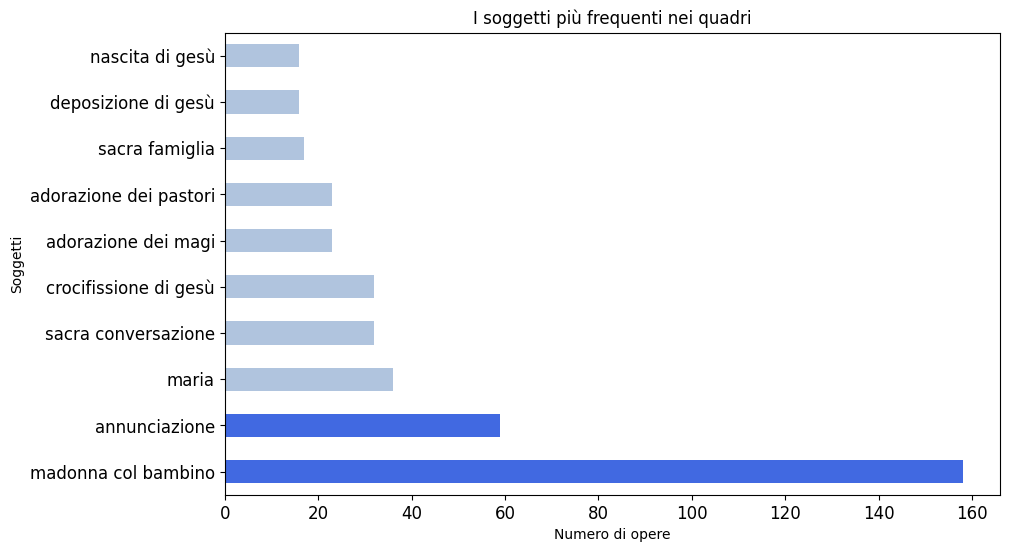

In [43]:
df_ridotto['soggetti'].str.split("; ").explode().value_counts().head(10).plot.barh(
    title='I soggetti più frequenti nei quadri',
    color= ["royalblue", "royalblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue"],
    fontsize= 12,
    figsize=(10,6),
    xlabel='Numero di opere',
    ylabel='Soggetti'
)

Il soggetto più frequente è _**Madonna col bambino**_, a seguire **_l'Annunciazione_**

Procediamo analizzando la colonna `contenuti` delle opere e contandone la frequenza.
Per prima cosa li separiamo (nel dataset sono scritti su una riga unica, divisi da un **;** ) e usiamo il metodo `.lower()` per renderla tutta in minuscolo.

In [44]:
df_ridotto['contenuti'] = df['contenuti'].str.lower() # Normalizzo tutti i generi in lettere minuscole
df_ridotto['contenuti'].str.split("; ").explode().value_counts() # separiamo i termini divisi da punto e virgola ed espandiamo la lista su più righe

,count
contenuti,
maria,251
bambino gesù,150
madonna col bambino,140
donna,130
gesù,127
...,...
daniele lo stilita,1
palazzo reale di torino,1
poesia,1


<Axes: title={'center': 'I contenuti  più frequenti nei quadri'}, xlabel='Numero di opere', ylabel='Contenuti'>

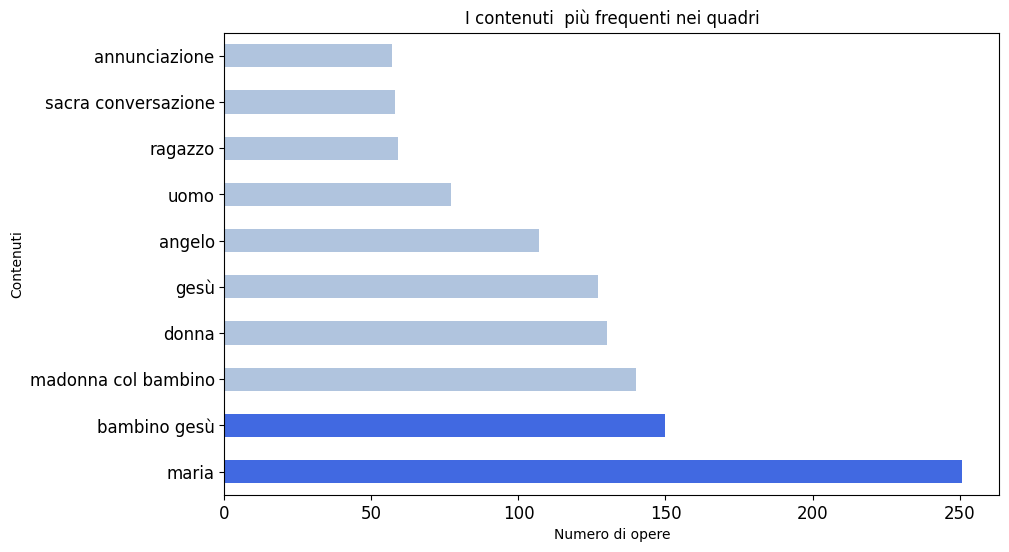

In [45]:
#visualizziamo il grafico a barre
df_ridotto['contenuti'].str.split("; ").explode().value_counts().head(10).plot.barh(
    title='I contenuti  più frequenti nei quadri',
    color= ["royalblue", "royalblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue"],
    fontsize= 12,
    figsize=(10,6),
    xlabel='Numero di opere',
    ylabel='Contenuti'
)

Come possiamo notare nel DataSet il contenuto che ha la più alta frequenza è **Maria**

I **movimenti artistici**, invece, vanno scritti in lettera maiuscola, quindi per visualizzare i valori normalizzati utilizzo `str.capitalize()` subito dopo `.explode()`, ma prima di `.value_counts()`, così da avere la certezza che uno stesso movimento non venga contateggiato due volte.

In [46]:
df_ridotto['movimenti'].str.split(";").explode().str.capitalize().value_counts()

,count
movimenti,
Pittura veneta,100
Manierismo,43
Alto rinascimento,41
Primo rinascimento,38
Barocco,27
alto rinascimento,24
Pittura rinascimentale italiana,20
Protorinascimento,14
Rinascimento italiano,13


<Axes: title={'center': 'I movimenti più diffusi nel Dataset'}, xlabel='Numero opere', ylabel='Movimenti'>

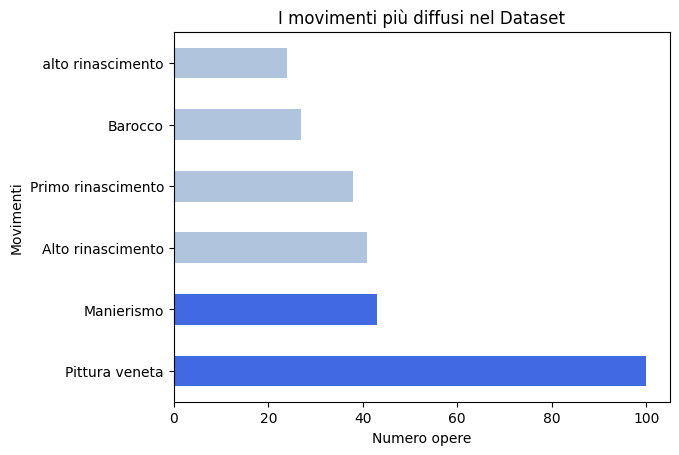

In [67]:
# ora continuamo con la normalizzazione dei valori dei movimenti
df_ridotto['movimenti'].str.split(";").explode().str.capitalize().value_counts().head(6).plot.barh(
    title= 'I movimenti più diffusi nel Dataset',
    color = ["royalblue" , "royalblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue"],
    ylabel= "Movimenti",
    xlabel= "Numero opere"
    )

In [48]:
df_ridotto['titolo'] = df['titolo'].str.capitalize()
df_ridotto['titolo'].str.split(";").explode()

,titolo
0,"Ritratto di fedra inghirami, detto fedra"
1,Nascita di venere
2,Ritratto di paolo iii con i nipoti alessandro ...
3,Pietà
4,Primavera
...,...
2439,Venere e satiro
2440,Ritratto del cardinale antonio agliardi
2441,Scena amorosa
2442,San benedetto revelli


A volte, durante la lettura o la manipolazione dei dati, i valori NaN (Not a Number) o altri indicatori di dati mancanti possono essere convertiti erroneamente in stringhe come 'nan' o 'none'. Creiamo un codice utilizzando il metodo `.replace()` per cercare queste specifiche stringhe e sostituirle con np.nan, che è la rappresentazione standard di NumPy per i valori mancanti.


In [49]:
# 2. Gestione dei valori nulli trasformati in stringhe "nan"
# Convertire in stringa fa sì che i NaN diventino il testo "nan": li ripristiniamo come valori nulli ufficiali

df_ridotto.replace({'nan': np.nan, 'none': np.nan}, inplace=True) #L'argomento inplace=True fa sì che la modifica venga applicata direttamente al DataFrame df_ridotto, senza creare una nuova copia.

Procedendo con la nostra domanda di ricerca, creaimo un nuovo DataFrame specifico per le opere dell'_Annuncizione_.

In [50]:
#Nuovo DataFrame denominato annunciazione_totale e
#filtriamo il DataFrame df_ridotto originale per includere solo le righe in cui la colonna 'soggetti' contiene la parola 'annunciazione'.
#na=False garantisce che le righe con valori mancanti (NaN) nella colonna 'soggetti' non causino errori e vengano escluse dal filtro.

annunciazione_totale = df_ridotto[
    df_ridotto['soggetti'].str.contains('annunciazione', case=False, na=False)
]

# Stampiamo titolo per indicare valore iniziale
print("\n--- Risultato con .str.contains() ---")

# Si estrae dalla colonna 'soggetti' solamente la parola 'annunciazione'
# ignorando altri testi presenti nella stessa cella
print(annunciazione_totale['soggetti'].str.extract(
    r'(?i)(annunciazione)', expand=False
))

#Ora abbiamo un elenco pulito di tutte le occorrenze del soggetto 'annunciazione' trovate


--- Risultato con .str.contains() ---
69      annunciazione
103     annunciazione
134     annunciazione
485     annunciazione
495     annunciazione
550     annunciazione
640     annunciazione
885     annunciazione
940     annunciazione
1339    annunciazione
1340    annunciazione
1411    annunciazione
1417    annunciazione
1418    annunciazione
1419    annunciazione
1420    annunciazione
1421    annunciazione
1422    annunciazione
1423    annunciazione
1424    annunciazione
1425    annunciazione
1426    annunciazione
1427    annunciazione
1428    annunciazione
1429    annunciazione
1430    annunciazione
1431    annunciazione
1432    annunciazione
1433    annunciazione
1434    annunciazione
1435    annunciazione
1436    annunciazione
1437    annunciazione
1438    annunciazione
1439    annunciazione
1448    annunciazione
1451    annunciazione
1452    annunciazione
1453    annunciazione
1454    annunciazione
1455    annunciazione
1456    annunciazione
1457    annunciazione
1458    annunci

In [51]:
#Contiamo quante volte il soggetto 'Annunciazione' appare nel nostro set di dati.
annunciazione_totale = df_ridotto[df_ridotto['soggetti'].str.contains('annunciazione', case=False, na=False)]
conteggio_totale_annunciazione = len(annunciazione_totale)

if conteggio_totale_annunciazione > 0:
    print(f"Il soggetto 'Annunciazione' è presente {conteggio_totale_annunciazione} volte nell'intero dataset.")
else:
    print("Il soggetto 'Annunciazione' non è presente nell'intero dataset.")

Il soggetto 'Annunciazione' è presente 59 volte nell'intero dataset.


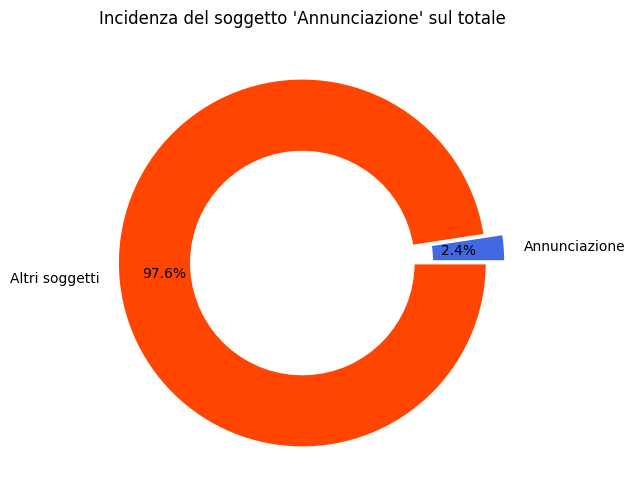

In [52]:
totale_opere = len(df_ridotto)
altri_soggetti = totale_opere - conteggio_totale_annunciazione

# Definiamo la variabile 'explode' per staccare la fetta 'Annunciazione'
explode = (0.1, 0) # 0.1 per la prima fetta (Annunciazione), 0 per la seconda (Altri soggetti)

plt.figure(figsize=(6, 6))
plt.pie([conteggio_totale_annunciazione, altri_soggetti],
        labels=['Annunciazione', 'Altri soggetti'],
        autopct='%1.1f%%', #Indica a Matplotlib di calcolare e formattare automaticamente il valore percentuale di ciascuna fetta
        pctdistance=0.75,  # Riposiziona il testo al centro dello spessore dell'anello
        explode=explode,  # Stacca la fetta 'Annunciazione' per evitare sovrapposizioni
        colors=['royalblue', 'orangered'],
      wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
)
plt.title("Incidenza del soggetto 'Annunciazione' sul totale")
plt.show()

In [53]:
annunciazione_totale.info()


<class 'pandas.core.frame.DataFrame'>
Index: 59 entries, 69 to 2416
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   titolo     59 non-null     object 
 1   secolo     16 non-null     Int64  
 2   soggetti   59 non-null     object 
 3   movimenti  3 non-null      object 
 4   contenuti  58 non-null     object 
 5   area       10 non-null     float64
 6   luoghi     57 non-null     object 
dtypes: Int64(1), float64(1), object(5)
memory usage: 3.7+ KB


**Domanda n. 1**

Per analizzare l'arco temporale in cui si concentra maggiormente il soggetto iconografico dell'_Annunciazione_ potrebbe essere utile individuare il periodo in cui sono state realizzate il maggior numero di opere.

In [54]:
df_ridotto['secolo'].value_counts().sort_index()
print(df_ridotto['secolo'].value_counts().sort_index())

secolo
11      1
13     23
14     42
15    196
16    502
17    222
18    135
19    206
20    146
21      5
Name: count, dtype: Int64


In [55]:
# Dataframe che conta quante opere sono presenti per ogni secolo.
# value_counts() calcola il numero di occorrenze di ogni secolo,
# mentre sort_index() ordina i secoli in ordine cronologico.
conteggio_per_secolo = (
    annunciazione_totale['secolo']
    .value_counts() #conta quante opere sono state realizzate in ciascun secolo.
    .sort_index() #ordina i risultati in base al loro indice, che in questo caso sono i numeri dei secoli.
)
# Stampa a video il numero di opere presenti per ciascun secolo.
print("--- Numero di opere 'Annunciazione' per secolo ---")
print(conteggio_per_secolo) #il risultato viene assegnato a questa variabile

--- Numero di opere 'Annunciazione' per secolo ---
secolo
11    1
14    2
15    2
16    6
17    4
18    1
Name: count, dtype: Int64


Ora visualizziamo i risultati in un grafico a barre orizzontali.

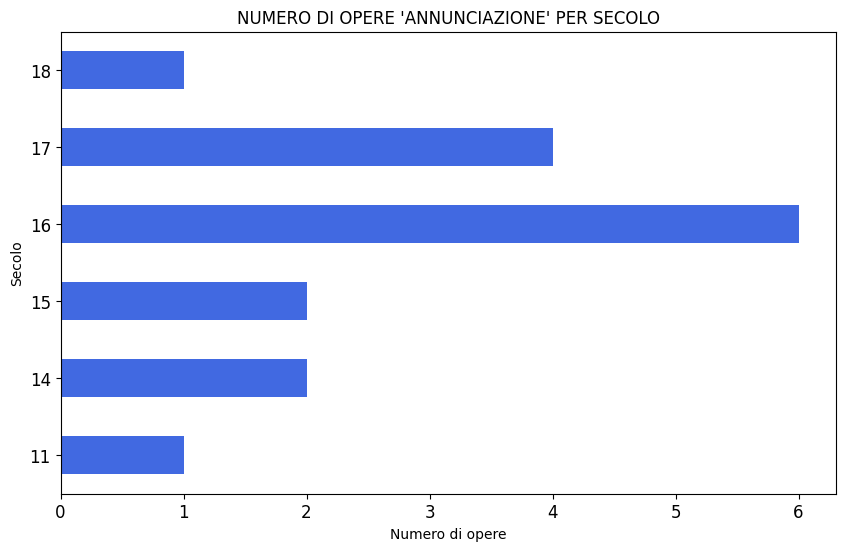

In [56]:
conteggio_per_secolo = annunciazione_totale['secolo'].value_counts().sort_index()

conteggio_per_secolo.plot.barh(
    title= "NUMERO DI OPERE 'ANNUNCIAZIONE' PER SECOLO",
    color="royalblue",
    fontsize=12,
    figsize=(10, 6),
    xlabel="Numero di opere",
    ylabel="Secolo"
)

plt.show()

Il 16° secolo rappresenta il picco produttivo per l'iconografia dell'_Annunciazione_. Ora vogliamo verificare attraverso il grafico a torta il rapporto tra le opere dell'_Annunciazione_ la cui datazione è accertata e quelle ancora prive di un secolo attribuito.

Opere con secolo noto: 16 su 59 (27.1%)
Opere senza secolo noto: 43 su 59 (72.9%)


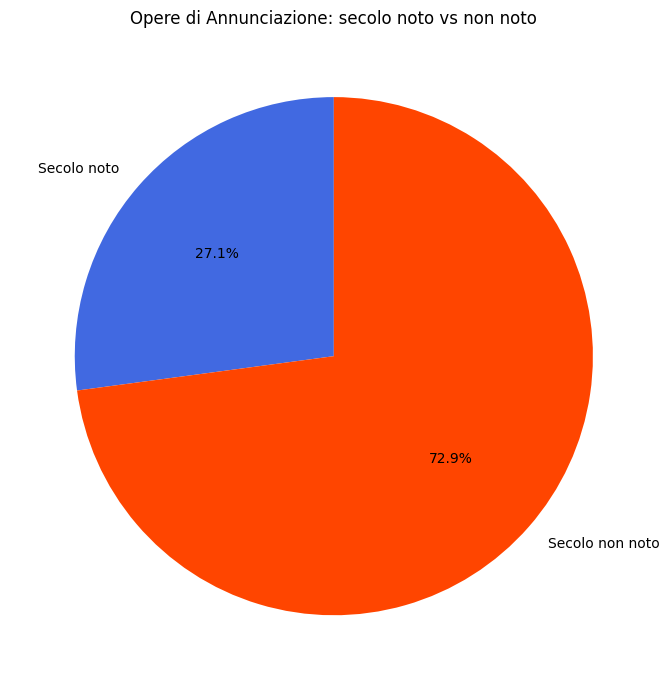

In [57]:
# Quante opere di Annunciazione hanno un secolo noto vs quante no
n_totale = len(annunciazione_totale)
n_con_secolo = annunciazione_totale['secolo'].notna().sum()
n_senza_secolo = n_totale - n_con_secolo

print(f"Opere con secolo noto: {n_con_secolo} su {n_totale} "
      f"({n_con_secolo/n_totale*100:.1f}%)")

print(f"Opere senza secolo noto: {n_senza_secolo} su {n_totale} "
      f"({n_senza_secolo/n_totale*100:.1f}%)")

# Grafico a torta
labels = ['Secolo noto', 'Secolo non noto']
values = [n_con_secolo, n_senza_secolo]

plt.figure(figsize=(7, 7))
plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=[ "royalblue", "orangered",
    ], # 'royalblue' per il secolo noto, 'orangered' per il secolo non noto
)

plt.title('Opere di Annunciazione: secolo noto vs non noto')
plt.tight_layout() #Regola automaticamente i parametri del layout per dare spazio agli elementi del grafico.
plt.show() #visualizziamo il grafico

Per rispondere compiutamente al primo quesito di ricerca, estendiamo l'analisi esplorativa esaminando quali sono i principali stili artistici che caratterizzano la produzione.

Per analizzare i movimenti artistici in cui il soggetto dell'Annunciazione è maggiormente frequente si è prima analizzato la colonna dei `movimenti` per vedere quali tra loro presentano le maggiori rappresentazioni di scene dell'Annunciazione.

In [58]:
# Separiamo i movimenti divisi da ';' ed esplodiamo la lista per avere una riga per ogni singolo movimento
movimenti_singoli = (
    annunciazione_totale['movimenti']
    .dropna() #Rimuove qualsiasi riga in cui il valore nella colonna 'movimenti' sia mancante (NaN), garantendo di lavorare solo con dati presenti
    .astype(str) #Converte tutti i valori rimanenti in stringhe
    .str.split(';')
    .explode() #Trasforma ogni elemento di queste liste create da .str.split() in una riga separata.
    .str.strip() #imuove eventuali spazi bianchi all'inizio e alla fine di ogni nome di movimento, per garantire la coerenza
    .str.lower()
)
# Conteggio delle frequenze ed eliminazione di 'non specificato'
conteggio_movimenti = movimenti_singoli[movimenti_singoli != 'non specificato'].value_counts()

# Output a schermo dei primi risultati
print("Frequenza dei movimenti artistici:")
print(conteggio_movimenti.head(10))

Frequenza dei movimenti artistici:
movimenti
alto rinascimento     2
pittura veneta        1
primo rinascimento    1
Name: count, dtype: int64


Movimenti come "_Alto Rinascimento_" e "_Pittura Veneta_" compaiono come voci distinte e conteggiate singolarmente, abbiamo così risolto il problema delle etichette composte.

Text(0, 0.5, 'movimenti')

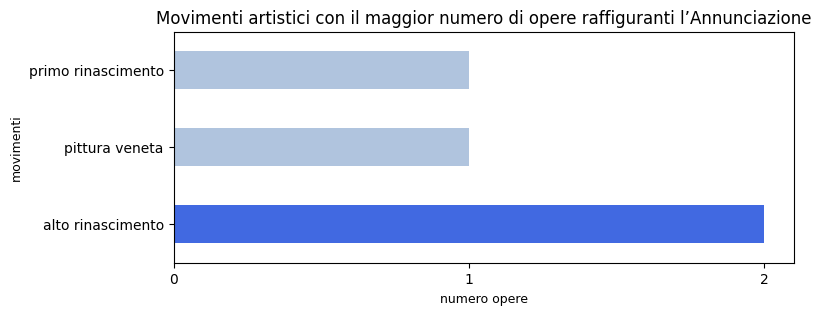

In [59]:
#In Matplotlib strumento dedicato al controllo preciso delle scale, dei segni di spunta (ticks)
#e delle relative etichette numeriche o testuali sugli assi (x e y) dei grafici.
import matplotlib.ticker as mticker

ax = conteggio_movimenti.plot.barh(
    figsize=(8, 3),
    fontsize=10,
    title="Movimenti artistici con il maggior numero di opere raffiguranti l’Annunciazione",
    color=["royalblue", "Lightsteelblue", "Lightsteelblue"],
)

#Imposta le tacche dell'asse X esclusivamente su valori interi
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax.set_xlabel("numero opere", fontsize=9)
ax.set_ylabel("movimenti", fontsize=9)


## 4.3 **Domanda n.2** - Calcolo dell'area per secolo per le opere dell'Annunciazione

Proseguiamo con la seconda domanda di ricerca andando ad analizzare l'area dei quadri raffiguranti l'_Annunciazione_ nei diversi secoli. Osserviamo come si distruibuisce negli anni la grandezza dell'_Annunciazione_.


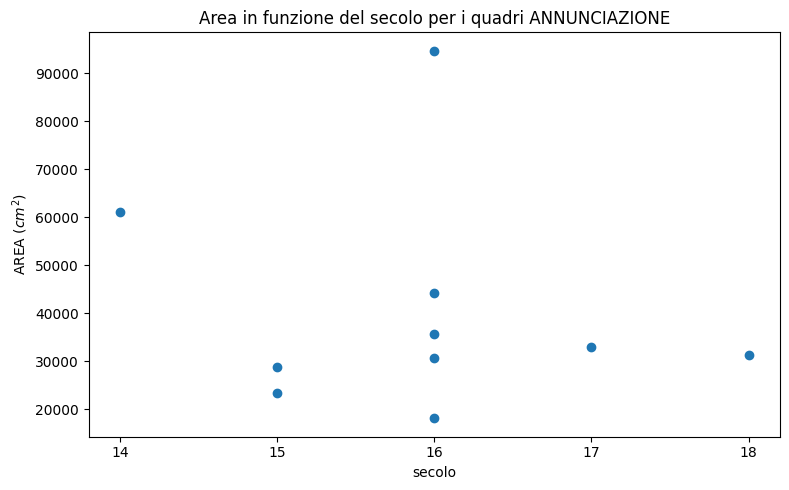

In [60]:
import matplotlib.ticker as mticker

# 1. Filtriamo i dati rimuovendo le righe con valori mancanti
df_plot = annunciazione_totale.dropna(subset=["secolo", "area"]).copy()

# Assicuriamo che i secoli siano espressi come numeri interi
df_plot["secolo"] = df_plot["secolo"].astype(int)

# 2. Creiamo lo scatter plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_plot["secolo"], df_plot["area"], color="tab:blue")

# 3. Correzione dell'asse X: definiamo esattamente quali tacche mostrare
secoli_unici = sorted(df_plot["secolo"].unique())
ax.set_xticks(secoli_unici)

# Aggiungiamo un formatter per l'asse x per visualizzare solo numeri interi
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

# 4. Personalizzazione di titoli ed etichette
ax.set_title("Area in funzione del secolo per i quadri ANNUNCIAZIONE")
ax.set_xlabel("secolo")
ax.set_ylabel("AREA ($cm^2$)")

# Layout ottimizzato
fig.tight_layout()

# Visualizzazione
plt.show()

 Il $16^\circ$ secolo non solo presenta il maggior numero di attestazioni, ma mostra anche la più elevata dispersione dimensionale, spaziando da opere di formato contenuto (sotto i $20.000 \text{ cm}^2$) fino a una monumentale opera di oltre $90.000 \text{ cm}^2$.

##4.3 **Domanda n. 3** - In quali musei sono conservate le opere raffiguranti l'_Annunciazione_
In linea con il terzo obiettivo di ricerca, si intende valutare in quali musei si concentrano le opere dell'_Annunciazione_ attraverso l'analisi della colonna `luoghi`


In [61]:
#Prendiamo il DataFrame creato per l'Annunciazione
annunciazione_totale["luoghi"]

,luoghi
69,chiesa di San Salvador
103,Palazzo degli Uffizi
134,Galleria Palatina
485,Gallerie dell'Accademia
495,Scuola Grande di San Rocco
550,pieve di Santa Maria Assunta
640,NaN
885,Castello di Monselice; Palazzo Cini
940,santuario di Nostra Signora della Misericordia
1339,palazzo Bianco


In [62]:
luoghi_annunciazione = (
    annunciazione_totale['luoghi']
    .dropna()  # Rimuove i valori NaN
    .astype(str)  # Assicura che i valori siano trattati come stringhe
    .str.split(';')  # Suddivide la stringa per il separatore ';'
    .explode()  # Trasforma ogni elemento della lista in una nuova riga
    .str.strip()  # Rimuove spazi bianchi all'inizio e alla fine
    .str.lower()  # Converte in minuscolo
)

In [63]:
conteggio_luoghi = luoghi_annunciazione.value_counts()
conteggio_luoghi

,count
luoghi,
gallerie dell'accademia,3
pinacoteca nazionale di bologna,3
museo nazionale di ravenna,2
museo di palazzo pretorio,2
galleria palatina,1
scuola grande di san rocco,1
castello di monselice,1
pieve di santa maria assunta,1
santuario di nostra signora della misericordia,1


In [64]:
numero_totale_luoghi = luoghi_annunciazione.nunique()
print(f"Il numero totale di luoghi unici per le opere 'Annunciazione' è: {numero_totale_luoghi}")

Il numero totale di luoghi unici per le opere 'Annunciazione' è: 52


In [65]:
top10_luoghi = conteggio_luoghi.head(10)
top10_luoghi

,count
luoghi,
gallerie dell'accademia,3
pinacoteca nazionale di bologna,3
museo nazionale di ravenna,2
museo di palazzo pretorio,2
galleria palatina,1
scuola grande di san rocco,1
castello di monselice,1
pieve di santa maria assunta,1
santuario di nostra signora della misericordia,1


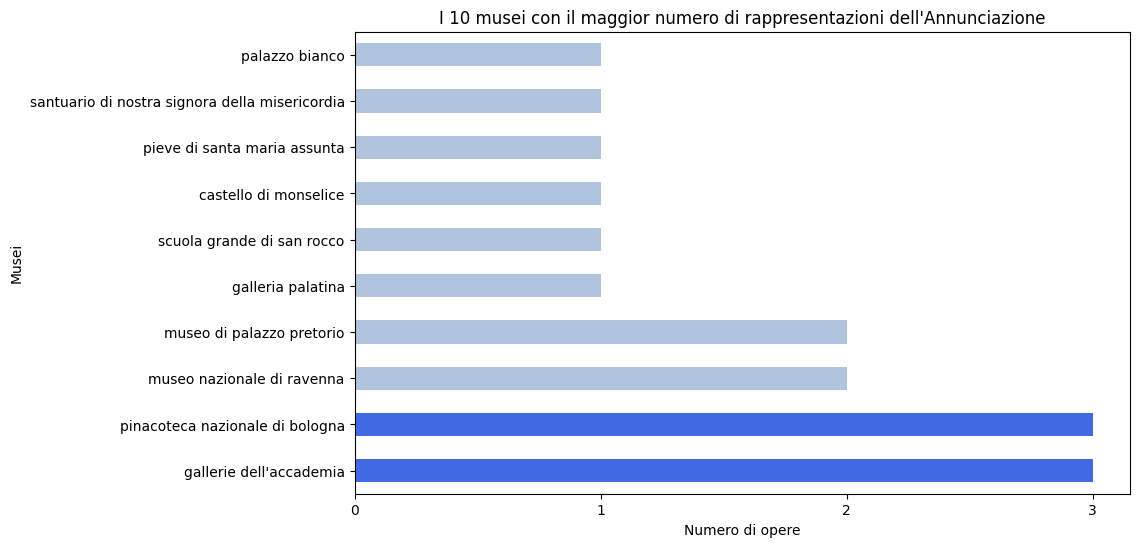

In [66]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# 1. Creazione del grafico tramite Pandas
ax = top10_luoghi.plot.barh(
    title="I 10 musei con il maggior numero di rappresentazioni dell'Annunciazione",
    color=["royalblue", "royalblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue", "Lightsteelblue",
    ],
    fontsize=10,
    figsize=(10, 6),
    xlabel="Numero di opere",
    ylabel="Musei",
)

# 2. Forziamo l'asse X a mostrare solo numeri interi
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# 3. Visualizzazione del grafico
plt.show()

Grazie a questa ricerca abbiamo constatato che le Gallerie dell'Accademia e la Pinacoteca Nazionale di Bologna sono i due musei in cui sono conservate il maggior numero di opere raffiguranti la scena sacra dell'_Annunciazione_.

##5. Conclusioni

La fase di esplorazione preliminare dei dati ci ha permesso di formulare tre domande di ricerca principali, i cui risultati esplicativi sintetizzano l'indagine condotta sul Dataset.

### **1. Frequenza e distribuzione cronologica dell'Annunciazione**
L'analisi si è concentrata sul soggetto dell'**_Annunciazione_**, individuato come uno dei temi iconografici sacri maggiormente rappresentati all'interno del corpus (preceduto per frequenza generale solo dalla raffigurazione della *Madonna col Bambino*). La nostra indagine ha evidenziato come la produzione di questa specifica iconografia raggiunga la sua massima concentrazione nel **XVI secolo (Cinquecento)**.

### **2. Analisi ed evoluzione dimensionale dell'_Annunciazione_**
I processi di pulizia e normalizzazione dei metadati relativi ad **altezza e larghezza** hanno consentito di calcolare l'area delle opere raffiguranti l'_Annunciazione_, al fine di verificare l'esistenza di variazioni dimensionali nel corso dei secoli. Dall'elaborazione dei dati è emerso che il sedicesimo secolo non solo presenta il maggior numero di attestazioni, ma mostra anche la più elevata dispersione dimensionale, spaziando da opere di formato contenuto (sotto i $20.000 \text{ cm}^2$) fino a una monumentale opera di oltre $90.000 \text{ cm}^2$.

### **3. I luoghi con maggiore frequenza dell'Annunciazione**
Per completare l'analisi svolta sul soggetto iconografico dell'Annunciazione abbiamo voluto svolgere un'analisi suoi luoghi in cui sono conservate il maggior numero di Annunciazioni.
L'analisi si è svolta prendendo in considerazione la colonna del DataFrame ridotto **luoghi** per poi concentrarsi solo sui musei in cui sono conservate opere di _Annunciazione_. Tra questi sono stati selezionati i primi 10 (cioè quelli che conservano il maggior numero di Annunciazioni) per poi realizzare un grafico a barre laterali.
Dall'elaborazione dei dati si è visto che le Gallerie dell'Accademia di Venezia e la Pinacoteca Nazionale di Bologna sono i due musei con il maggior numero di opere con soggetto iconografico de l'_Annunciazione_ al loro interno.